
**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update your Course 1 notebook with links to your own work once completed!

# Mini-project 5.3 Detecting the anomalous activity of a ship’s engine

## **Business context**
I've got a real data set to identify anomalous activity in a ship’s engine functionality (Devabrat,  2022). 

The data set contains six important features continuously monitored to evaluate the engine's status as ‘good’ or ‘bad’. These features are:
- **Engine rpm (revolutions per minute):** A high rpm indicates the engine is operating at a higher speed than designed for prolonged periods, which can lead to overheating, excessive wear, and eventual failure. A low rpm could signal a lack of power, issues with fuel delivery, or internal mechanical problems.
- **Lubrication oil pressure:** Low lubrication oil pressure indicates insufficient lubrication, leading to increased friction, overheating, and engine damage. A high lubrication oil pressure could signal a blockage in the oil delivery system, potentially causing seal or gasket failure.
- **Fuel pressure:** High fuel pressure can cause poor engine performance and incomplete combustion, indicating fuel pump or filter issues. A low fuel pressure may result in excessive fuel consumption, poor emissions, or damage to the fuel injectors.
- **Coolant pressure:** Low coolant pressure indicates a potential leak in the cooling system or a coolant pump failure, risking engine overheating. A high coolant pressure could be a sign of a blockage in the cooling system or a failing head gasket, which can also lead to overheating.
- **Lubrication oil temperature:** High lubrication oil temperature suggests the oil is overheating, which can degrade its lubricating properties and lead to engine damage. A low lubrication oil temperature may indicate it is not reaching its optimal operating temperature, potentially causing inadequate lubrication.
- **Coolant temperature:** High coolant temperature signals overheating, which various issues, including a failed thermostat, coolant leak, or insufficient coolant flow can cause. A low coolant temperature could suggest the engine is not reaching its optimal operating temperature, affecting performance and efficiency.

Issues with engines could lead to engine malfunctions, potential safety hazards, and downtime (e.g. delayed deliveries), resulting in the breakdown of a ship’s overall functionality, consequently impacting the business, such as affecting revenue via failure to deliver goods. By predicting timely maintenance, the business aims to increase profit by reducing downtime, reducing safety risks for the crew, limiting fuel consumption, and increasing customer satisfaction through timely deliveries.

I'll develop a robust anomaly detection system to protect a company’s shipping fleet by evaluating engine functionality. I'll explore the data and:
- employ preprocessing and feature engineering
- perform anomaly detection.

In the Notebook, I will:
- explore the data set
- preprocess the data and conduct feature engineering
- apply statistical techniques to detect anomalies
- use ML algorithms to detect anomalies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import math

# Data Import

In [2]:
# URL to import data set from GitHub
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

# Read the data into pandas dataframe
engine_data = pd.read_csv(url)

# Exploratory Data Analysis (EDA)

View Head

In [3]:
engine_data.head(5)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


Review Basic Summary Statistics

In [4]:
engine_data.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


Summarise other important statistics and confirm 0 missing values

In [5]:
# summarise mean vs. median and no. of NaN values

summary_table = pd.DataFrame({
    col: {"Mean": engine_data[col].mean(),
          "Median": engine_data[col].median(),
          "Missing Values": engine_data[col].isnull().sum()}
    for col in engine_data.columns})

summary_table = summary_table.round(2)
print(summary_table.T)

if engine_data.isnull().sum().sum() == 0:
    print("\nHurray! No missing values found.")
else:
    print("Missing values found.")

                    Mean  Median  Missing Values
Engine rpm        791.24  746.00             0.0
Lub oil pressure    3.30    3.16             0.0
Fuel pressure       6.66    6.20             0.0
Coolant pressure    2.34    2.17             0.0
lub oil temp       77.64   76.82             0.0
Coolant temp       78.43   78.35             0.0

Hurray! No missing values found.


Confirm no duplicates

In [6]:
# confirm no duplicates in dataset

if engine_data.duplicated().sum() == 0:
    print("\nHurray! No duplicates found.")
else:
    print("Duplicates found.")


Hurray! No duplicates found.


Visualise distributions with histograms

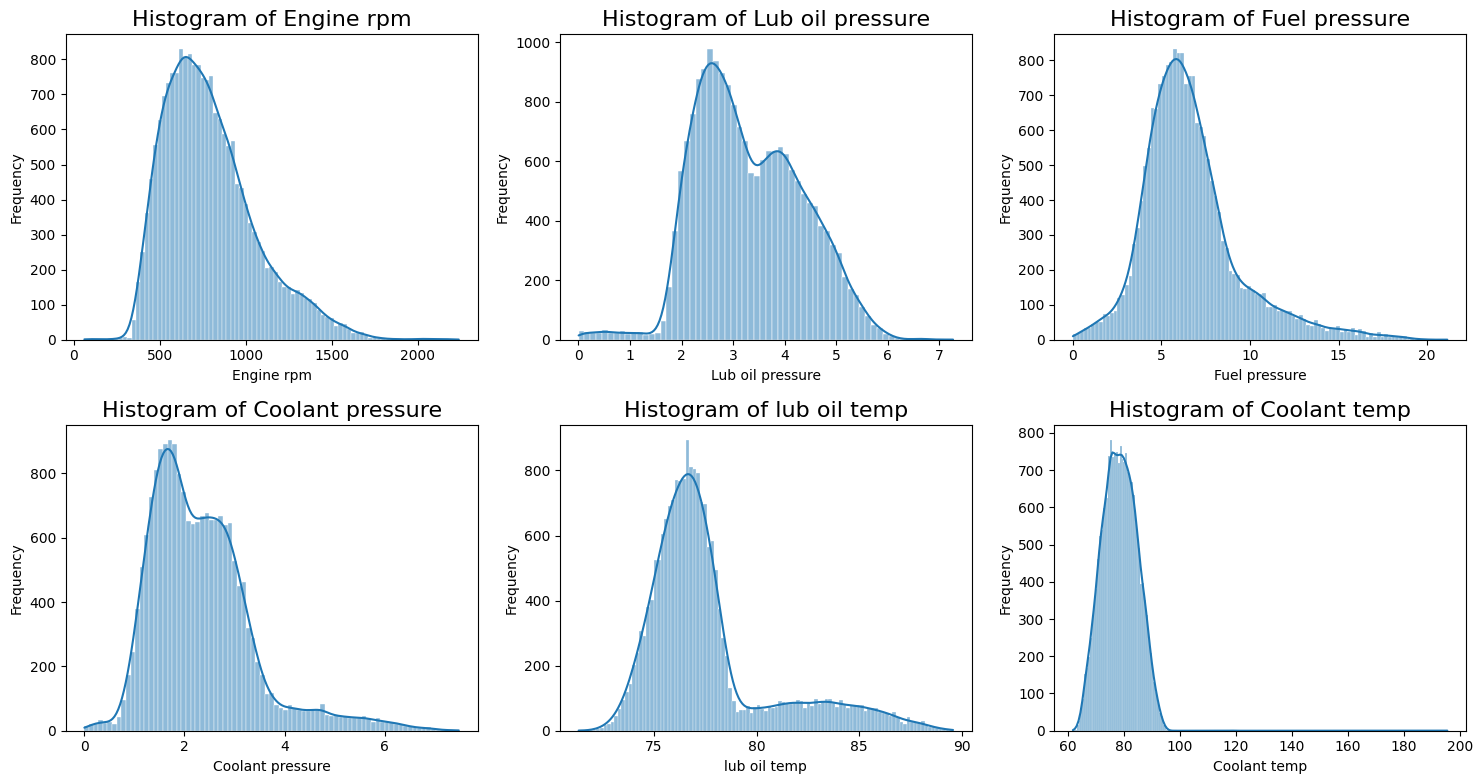

In [7]:
# calculate how many rows are needed to fit all columns

n_cols = 3
n_rows = math.ceil(len(engine_data.columns) / n_cols)

# create tight subplots and index in for loop

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# populate each subplot + set style

for i, col in enumerate(engine_data.columns):
    sns.set(style="whitegrid"),
    sns.histplot(engine_data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}', fontsize=16)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Visualise central measures of dispersion with boxplots

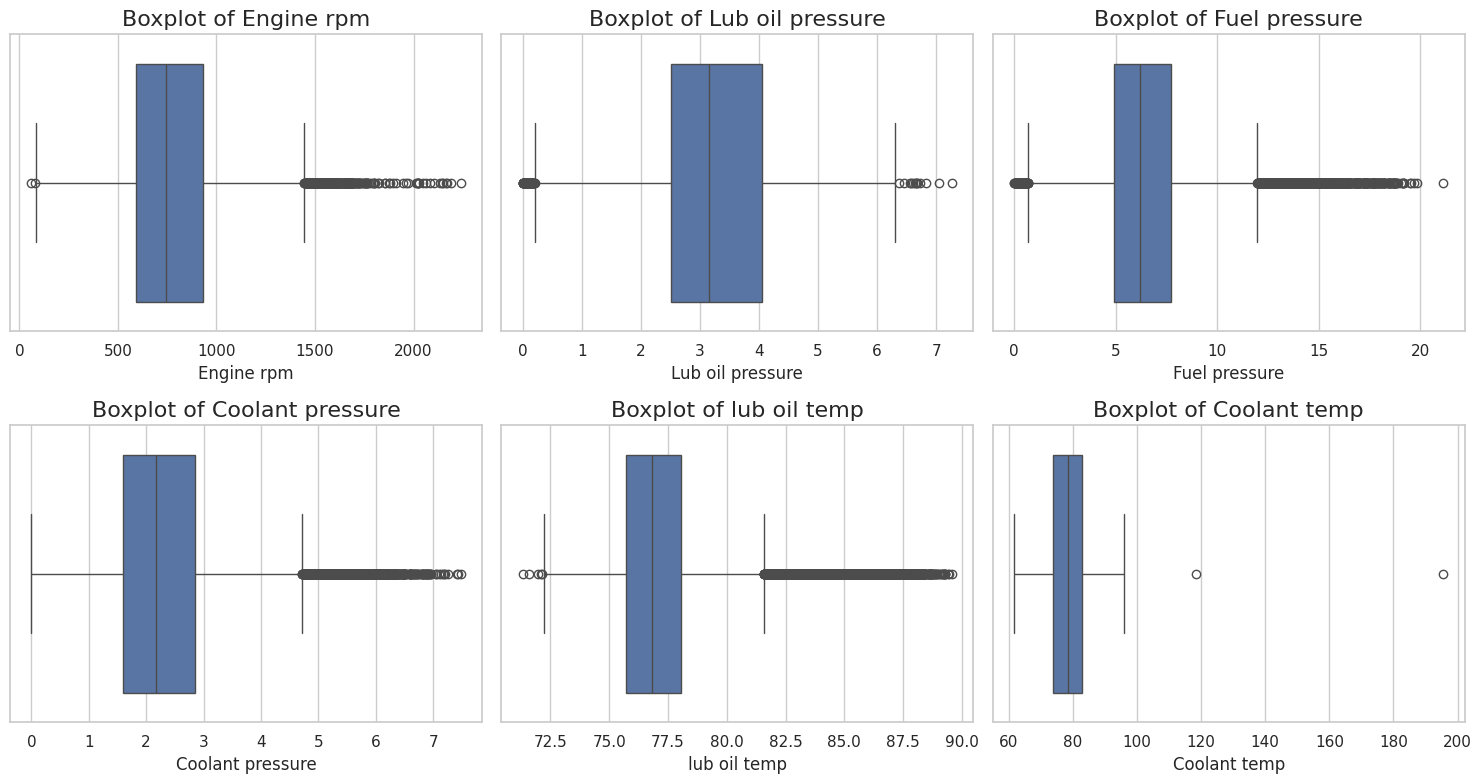

In [8]:
# recycle code from histplot above for boxplots

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(engine_data.columns):
    sns.set(style="whitegrid"),
    sns.boxplot(x=engine_data[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=16)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

# Identifying potential outliers with IQR

Analyse quantiles and IQR

In [9]:
# create a dataframe of IQR-specific descriptive stats

IQR_table = pd.DataFrame({
    col: {"Q1": engine_data[col].quantile(0.25),
          "Q3": engine_data[col].quantile(0.75),
          "IQR": engine_data[col].quantile(0.75) - engine_data[col].quantile(0.25)}
    for col in engine_data.columns})

IQR_table = IQR_table.round(2)
print(IQR_table.T)

                      Q1      Q3     IQR
Engine rpm        593.00  934.00  341.00
Lub oil pressure    2.52    4.06    1.54
Fuel pressure       4.92    7.74    2.83
Coolant pressure    1.60    2.85    1.25
lub oil temp       75.73   78.07    2.35
Coolant temp       73.90   82.92    9.02


Analyse dataset for outliers (using IQR) and translate relates to binary

In [10]:
# create empty dataframe

outliers_binary = pd.DataFrame(columns=engine_data.columns)

# classify outliers in binary form

for col in engine_data.columns:
  Q1 = engine_data[col].quantile(0.25)
  Q3 = engine_data[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - (1.5 * IQR)
  upper = Q3 + (1.5 * IQR)
  outliers_binary[col] = (engine_data[col] < lower) | (engine_data[col] > upper)
  outliers_binary[col] = outliers_binary[col].astype(int)


Visualise binary dataframe

In [11]:
 outliers_binary.head(5)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,0,0,0,0,0,0
1,0,0,0,1,0,0
2,0,0,0,0,1,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


Iteratively the increase number of features that must simultaneously be in outlier condition for a sample to be classified as an outlier - counting the number of rows that satisfy the criteria for n columns.

In [12]:
# add number of anomalies by summing each row

true_counts_per_row = outliers_binary.sum(axis=1)

# max number of features to be indexed momentarily

max_features = outliers_binary.shape[1]

IQR_outliers_array = (true_counts_per_row
                        .value_counts()
                        .reindex(range(0, max_features + 1), fill_value=0)
                        .sort_index()
                        )

IQR_outliers_df = pd.DataFrame({
    "Number of Outlier Features": IQR_outliers_array.index,
    "Number of Rows": IQR_outliers_array.values
})

IQR_outliers_df['% of Total'] = IQR_outliers_df['Number of Rows'] / IQR_outliers_df['Number of Rows'].sum() * 100
IQR_outliers_df['% of Total'] = IQR_outliers_df['% of Total'].astype(float).round(2)

IQR_outliers_df

,Number of Outlier Features,Number of Rows,% of Total
0,0,14899,76.27
1,1,4214,21.57
2,2,411,2.10
3,3,11,0.06
4,4,0,0.00
5,5,0,0.00
6,6,0,0.00


Univariate IQR analysis classified 14,899 observations (76.3%) as fully normal, while 4,214 observations (21.6%) contained at least one anomalous feature –
demonstrating that univariate IQR analysis alone was insufficient for row-level
anomaly classification.

Additional: Visualise outlier trend for n features

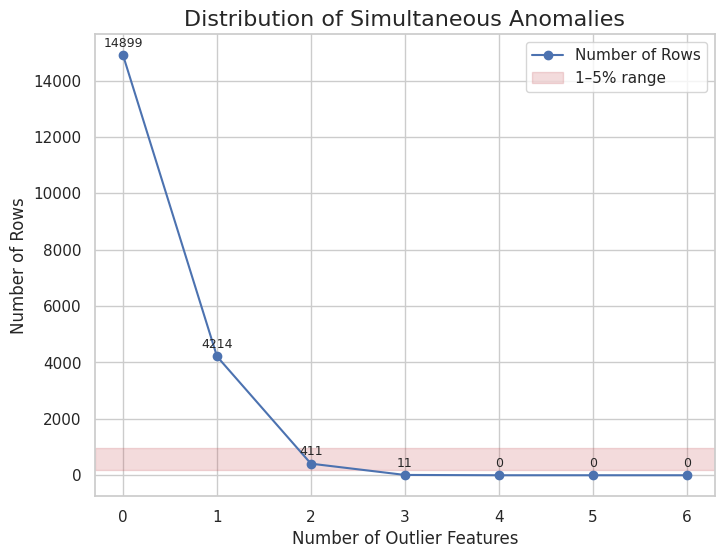

In [13]:
# create visualisation of multivariate outlier trends

# compute threshold (in count) for visualisation

total_rows = 19535
lower_1pct = total_rows * 0.01
upper_5pct = total_rows * 0.05

# plot outlier df in lineplot

ax = IQR_outliers_df.plot(
    x="Number of Outlier Features",
    y="Number of Rows",
    kind="line",
    marker='o',
    figsize=(8, 6))

# plot the exact row count above each marker

for x, y in zip(IQR_outliers_df["Number of Outlier Features"],
                IQR_outliers_df["Number of Rows"]):
    ax.annotate(
        f"{y}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 6),
        ha='center',
        fontsize=9)

# shaded area represents upper and lower outlier thresholds
plt.axhspan(lower_1pct, upper_5pct, color='r', alpha=0.2, label='1–5% range')

plt.ylabel("Number of Rows")
plt.title("Distribution of Simultaneous Anomalies", fontsize=16)
plt.legend()
plt.show()

In [14]:
# check whether row (and corresponding number of features) satisfies 1-5% threshold

for index, row in IQR_outliers_df.iterrows():
  if row['% of Total'] > 1 and row['% of Total'] < 5:
    print(f"{row['Number of Outlier Features']:.0f} anomalous features meet outlier threshold requirements (1-5%)")

2 anomalous features meet outlier threshold requirements (1-5%)


Rows with two simultaneous anomalous features met the predefined anomaly
threshold (2.10%).

# Data Preprocessing

Feature Scaling: Standardisation

In [15]:
# scale data with standardisation so that data is compatible with OCSVM

scaler = StandardScaler()
scaled_engine_data = scaler.fit_transform(engine_data)

scaled_engine_data = pd.DataFrame(scaled_engine_data, columns=engine_data.columns)

scaled_engine_data.head(5)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491


Feature scaling was applied, as required for the OCSVM model.

PCA (for Visualisation Only): 2 Features Only

In [16]:
# generate PCA object that is to be used later in data visualisation

pca = PCA(n_components=2)
engine_data_pca = pca.fit_transform(scaled_engine_data)
engine_data_pca = pd.DataFrame(engine_data_pca, columns=['PC1', 'PC2'])

engine_data_pca.head(5)

,PC1,PC2
0,-0.557362,-0.906512
1,-2.177170,-1.201538
2,2.051806,1.039581
3,0.744375,-0.501140
4,-1.629821,-0.473906


Principal Component Analysis (PCA) was used to reduce the six original features to two components for visualising anomalies detected by the unsupervised learning models.

Check PCA has been executed correctly and evaluate explained variance

In [17]:
# compare shape of standardise and PCA-reduced data

print("Standardised data: ", scaled_engine_data.shape)
print("PCA data: ", engine_data_pca.shape)

Standardised data:  (19535, 6)
PCA data:  (19535, 2)


Explained Variance

In [18]:
# evaluate variance explained by the two components

# create a DataFrame
explained_variance_df = pd.DataFrame({
    'PC': range(1, len(pca.explained_variance_ratio_) + 1),
    'Explained Variance': pca.explained_variance_ratio_
})

print(explained_variance_df.round(2))

   PC  Explained Variance
0   1                0.19
1   2                0.18


The proportion of variance explained by these components was evaluated separately to contextualise the limitations of visualisations.

# Hyperparameter Tuning with One-Class Single Vector Machine (OCSVM)

Defining functions to ensure testing efficiency: fitting and predicting y with OCSVM

In [19]:
# define functon that fits a model with a custom gamma & nu + returns a df with y_pred

def compute_SVM(scaled_df, gamma, nu):
  model = OneClassSVM(kernel='rbf', gamma=gamma, nu=nu)
  model.fit(scaled_df)

  y_pred = model.predict(scaled_df)
  y_pred = pd.Series(y_pred)

  df = pd.DataFrame(scaled_df.copy(), columns=engine_data.columns)
  df['Anomalies'] = y_pred
  return df

Defining functions to ensure testing efficiency: concatenating PCA features with y_pred

In [20]:
# define function that joins df y_pred with PCA object

def concat_y_PCA(pca_df, y_pred):
  df = pd.concat([pca_df, y_pred], axis=1)
  return df

Defining functions to ensure testing efficiency: Visualising PCA-reduced data with ML-generated y_pred (used for both OCSVM & ISOF)

In [21]:
# define function that plots PCA-object with y_pred

def plot_outliers(df, title):
    fig, ax = plt.subplots(figsize=(10,8))
    sns.set(style="whitegrid")
    ax.scatter(df.loc[df['Anomalies'] == 1, 'PC1'],
               df.loc[df['Anomalies'] == 1, 'PC2'],
               c='blue',
               marker='o',
               alpha=0.6,
               label='Non-Anomalies')
    ax.scatter(df.loc[df['Anomalies'] == -1, 'PC1'],
               df.loc[df['Anomalies'] == -1, 'PC2'],
               c='red',
               marker='x',
               label='Anomalies')
    ax.set_title(title, fontsize=18)
    ax.legend()
    plt.show()

Defining functions to ensure testing efficiency: Anomaly Analysis Dataframe

In [22]:
# define function that plots model specific stats (without needing .T)

def anomaly_analysis(df):
  anomalies_df = pd.DataFrame({
    "Metric": [
        "Total Number of Samples",
        "Number of Non-anomalies",
        "Number of Anomalies",
        "% of Non-anomalies",
        "% of Anomalies"
    ],
    "Value": [
        df.shape[0],
        (df['Anomalies'] == 1).sum(),
        (df['Anomalies'] == -1).sum(),
        (df['Anomalies'] == 1).sum() / df.shape[0] * 100,
        (df['Anomalies'] == -1).sum() / df.shape[0] * 100
    ]
  })
  return anomalies_df

**1. One-Class Single Vector Machine (SVM): gamma = 0.1, nu = 0.05**

Fitting the model and predicting y (number of anomalies)

In [23]:
SVM_1 = compute_SVM(scaled_engine_data, 0.1, 0.05)

Sense-checking output:

In [24]:
SVM_1.head(5)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Anomalies
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412,1
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158,-1
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690,1
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913,1
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491,1


Evaluating number of anomalies identified:

In [25]:
anomaly_analysis(SVM_1).round(2)

,Metric,Value
0,Total Number of Samples,19535.00
1,Number of Non-anomalies,18557.00
2,Number of Anomalies,978.00
3,% of Non-anomalies,94.99
4,% of Anomalies,5.01


Visualise anomalies vs. non-anomalies with PCA plot:

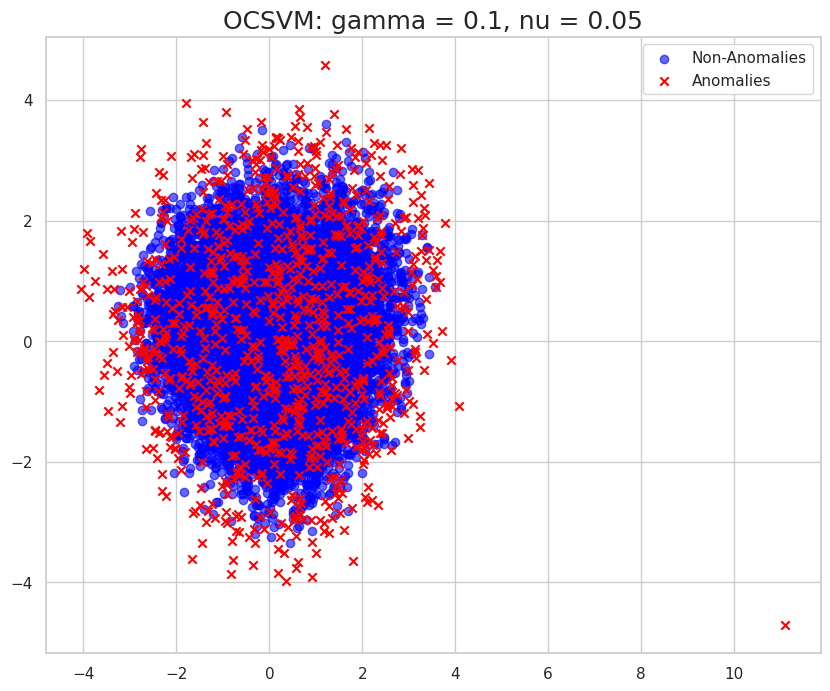

In [26]:
SVM_1_PCA = concat_y_PCA(engine_data_pca, SVM_1['Anomalies'])
plot_outliers(SVM_1_PCA, 'OCSVM: gamma = 0.1, nu = 0.05')

OCSVM anomalies are broadly distributed around the cluster periphery, with an
additional concentration in the lower region of the cluster (gamma = 0.1, nu = 0.05).

**2. One-Class Single Vector Machine (SVM): gamma = 0.1, nu = 0.01**

Fitting the model and predicting y (number of anomalies). Subsequently, evaluating a number of anomalies identified.

In [27]:
SVM_2 = compute_SVM(scaled_engine_data, 0.1, 0.01)
anomaly_analysis(SVM_2).round(2)

,Metric,Value
0,Total Number of Samples,19535.00
1,Number of Non-anomalies,19346.00
2,Number of Anomalies,189.00
3,% of Non-anomalies,99.03
4,% of Anomalies,0.97


Visualise anomalies vs. non-anomalies with PCA plot:


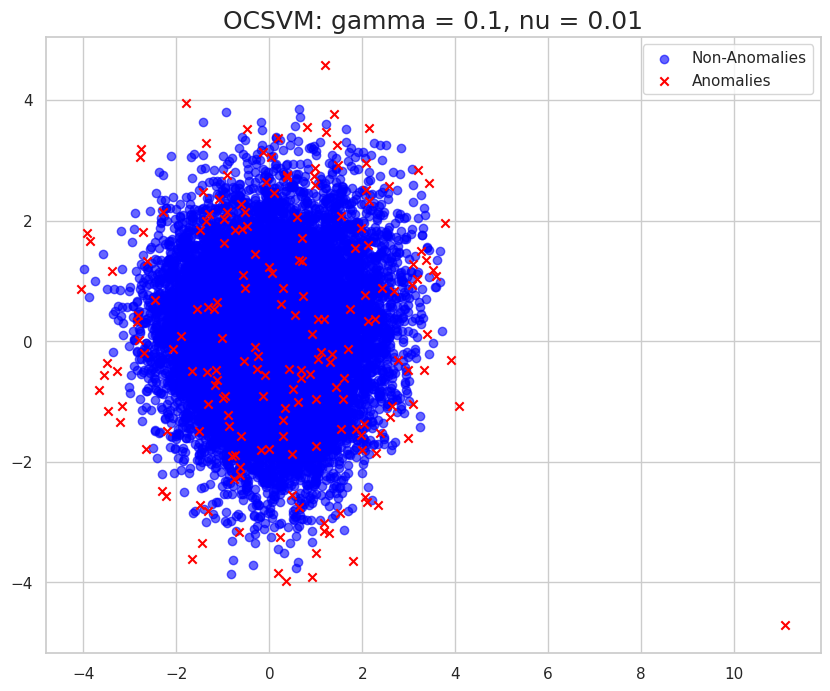

In [28]:
SVM_2_PCA = concat_y_PCA(engine_data_pca, SVM_2['Anomalies'])
plot_outliers(SVM_2_PCA, 'OCSVM: gamma = 0.1, nu = 0.01')

Reducing nu means fewer anomalies allowed, number of anomalies detected drops. Anomalies detection appear visually around the normal observation cluster as well as within i , significantly fewer detections than with nu = 0.05.

**3. One-Class Single Vector Machine (SVM): gamma = 0.5, nu = 0.01**

Fitting the model and predicting y (number of anomalies). Subsequently, evaluating a number of anomalies identified.

In [29]:
SVM_3 = compute_SVM(scaled_engine_data, 0.5, 0.01)
anomaly_analysis(SVM_3).round(2)

,Metric,Value
0,Total Number of Samples,19535.00
1,Number of Non-anomalies,18924.00
2,Number of Anomalies,611.00
3,% of Non-anomalies,96.87
4,% of Anomalies,3.13


Visualise anomalies vs. non-anomalies with PCA plot:

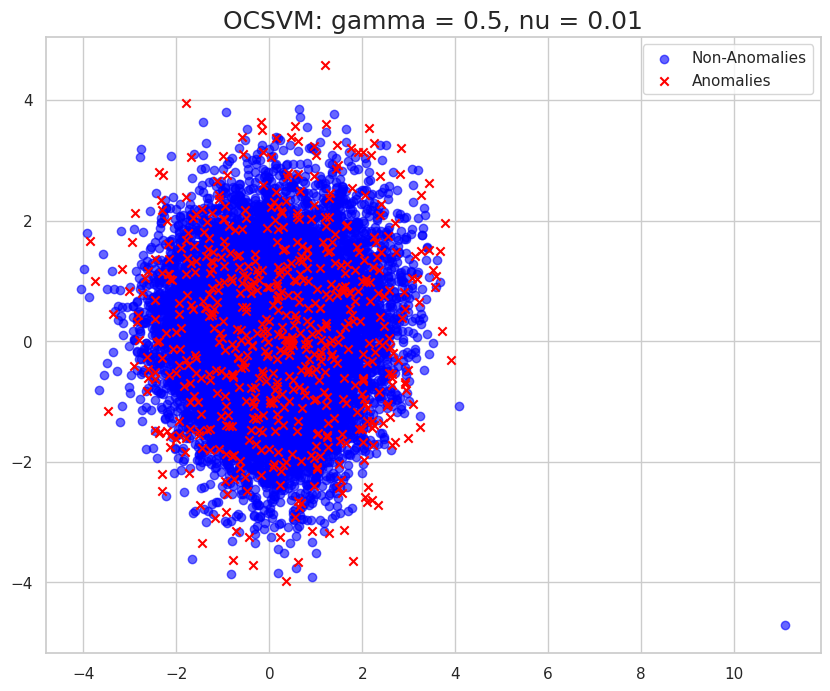

In [30]:
SVM_3_PCA = concat_y_PCA(engine_data_pca, SVM_3['Anomalies'])
plot_outliers(SVM_3_PCA, 'OCSVM: gamma = 0.5, nu = 0.01')

Alternatively, increasing gamma to 0.05 means more a complex decision boundary, fitting local structure more closely (points may be classified as anomalies if they deviate locally). Compared with SVM 1 (gamma = 0.01, nu = 0.05), this model has more concentration to anomalies detected within the normal observation cluster. Points towards the edge of the cluster seem less likely to be classified as anomalous; potentially suggesting that this hyperparameter combination is less accurate.

# Hyperparameter Tuning with Isolation Forest

Change plot colours for visual clarity:

In [31]:
# anomalies detected with Isolation Forest will be magenta

def plot_outliers(df, title):
    fig, ax = plt.subplots(figsize=(10,8))
    sns.set(style="whitegrid")
    ax.scatter(df.loc[df['Anomalies'] == 1, 'PC1'],
               df.loc[df['Anomalies'] == 1, 'PC2'],
               c='blue',
               marker='o',
               alpha=0.6,
               label='Non-Anomalies')
    ax.scatter(df.loc[df['Anomalies'] == -1, 'PC1'],
               df.loc[df['Anomalies'] == -1, 'PC2'],
               c='magenta',
               marker='x',
               label='Anomalies')
    ax.set_title(title, fontsize=18)
    ax.legend()
    plt.show()

Define function for fitting and predicting with isolation forest:

In [32]:
def compute_ISO(X, n_estimators, contamination):
  iso_forest = IsolationForest(n_estimators=n_estimators,
                               contamination=contamination,
                               random_state=42)
  iso_forest.fit(X)

  y_pred = iso_forest.predict(X)
  y_pred = pd.Series(y_pred)

  df = pd.DataFrame(X.copy(), columns=engine_data.columns)
  df['Anomalies'] = y_pred
  return df

**1. Isolation Forest: n_estimators = 100, contamination = 0.05**

In [33]:
IsolationForest_1 = compute_ISO(engine_data, 100, 0.05)

IsolationForest_1.head(5)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Anomalies
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,1
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,-1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,1
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,1


Evaluating the number of anomalies:

In [34]:
anomaly_analysis(IsolationForest_1).round(2)

,Metric,Value
0,Total Number of Samples,19535.0
1,Number of Non-anomalies,18558.0
2,Number of Anomalies,977.0
3,% of Non-anomalies,95.0
4,% of Anomalies,5.0


Visualise anomalies vs. non-anomalies with PCA plot:

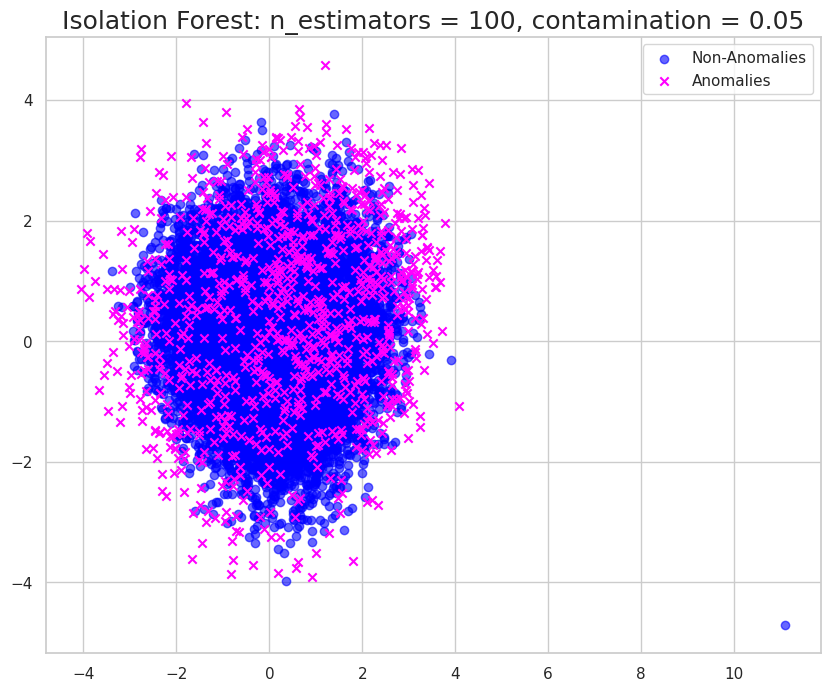

In [35]:
IsolationForest_PCA_1 = concat_y_PCA(engine_data_pca,
                                     IsolationForest_1['Anomalies'])
plot_outliers(IsolationForest_PCA_1,
              'Isolation Forest: n_estimators = 100, contamination = 0.05')

Compared to SVM 1 (5% anomalies detected), Isolation Forest anomalies exhibit a more localised concentration in the upper-right region of the normal observation cluster. Though similarly, anomalies are broadly distributed around the cluster periphery.

**2. Isolation Forest: n_estimators = 50, contamination = 0.04**

In [36]:
IsolationForest_2 = compute_ISO(engine_data, 50, 0.04)

IsolationForest_2.head(5)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Anomalies
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,1
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,-1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,1
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,1


Evaluating the number of anomalies:

In [37]:
anomaly_analysis(IsolationForest_2).round(2)

,Metric,Value
0,Total Number of Samples,19535.0
1,Number of Non-anomalies,18753.0
2,Number of Anomalies,782.0
3,% of Non-anomalies,96.0
4,% of Anomalies,4.0


Visualise anomalies vs. non-anomalies with PCA plot:

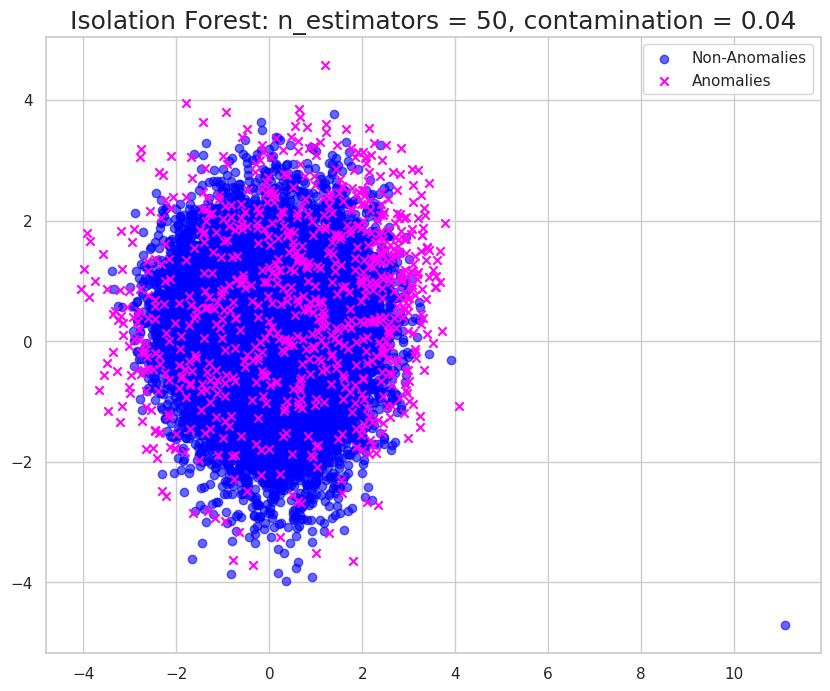

In [38]:
IsolationForest_PCA_2 = concat_y_PCA(engine_data_pca,
                                     IsolationForest_2['Anomalies'])
plot_outliers(IsolationForest_PCA_2,
              'Isolation Forest: n_estimators = 50, contamination = 0.04')

Less anomalies appear to have been classified in the lower region of this cluster's periphery. Whereas, concentration appears to be relatively stable (compared with IsolationForest_1) in the upper right region.

**3. Isolation Forest: n_estimators = 100, contamination = 0.01**

In [39]:
IsolationForest_3 = compute_ISO(engine_data, 100, 0.01)

IsolationForest_3.head(5)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Anomalies
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,1
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,1
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,1


Evaluating the number of anomalies:

In [40]:
anomaly_analysis(IsolationForest_3).round(2)

,Metric,Value
0,Total Number of Samples,19535.0
1,Number of Non-anomalies,19339.0
2,Number of Anomalies,196.0
3,% of Non-anomalies,99.0
4,% of Anomalies,1.0


Visualise anomalies vs. non-anomalies with PCA plot:

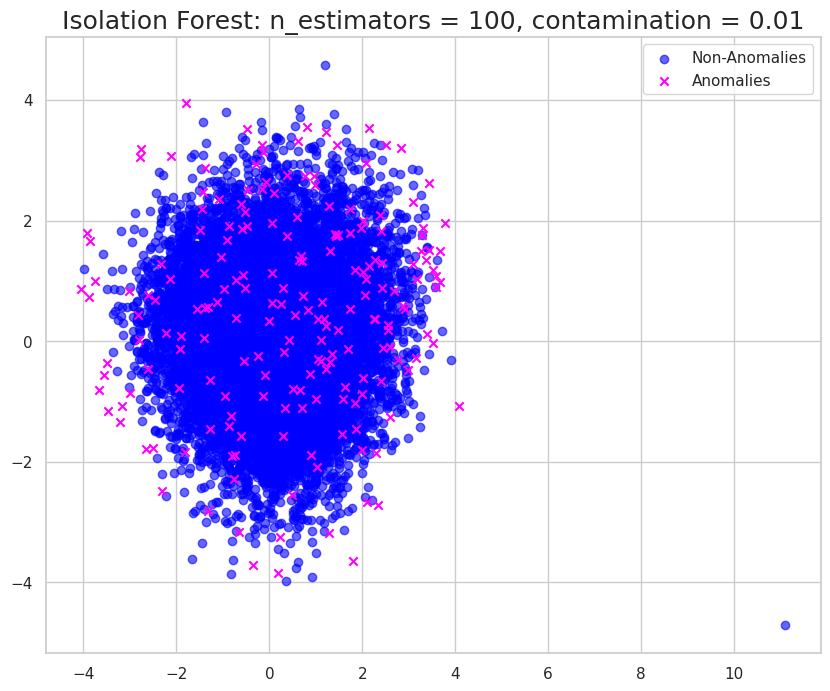

In [41]:
IsolationForest_PCA_3 = concat_y_PCA(engine_data_pca,
                                     IsolationForest_3['Anomalies'])
plot_outliers(IsolationForest_PCA_3,
              'Isolation Forest: n_estimators = 100, contamination = 0.01')

IsolationForest_3, which is configured to the minimum threshold of anomalies detected (1%) shows some concentration of anomalies around the cluster's periphery as well as coverage of the cluster's centre.

# Assessing Consistency across OCSVM and Isolation Forest

Adding both y_preds back to original dataset:

In [42]:
engine_data_full = engine_data

engine_data_full['Anomalies_SVM'] = SVM_1['Anomalies']

engine_data_full['Anomalies_ISOF'] = IsolationForest_1['Anomalies']

engine_data_full.head(5)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Anomalies_SVM,Anomalies_ISOF
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,1,1
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,-1,-1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,1,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,1,1
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,1,1


Converting to binary and renaming in order to retrieve summary statistics:

In [43]:
# converting back to binary, if SVM and ISOF are both -1 = 1

engine_data_full['Anomalies_Final'] = engine_data_full[['Anomalies_SVM', 'Anomalies_ISOF']].apply(lambda x: 1 if all(x == -1) else 0, axis=1)

engine_data_full_binary = engine_data_full.drop(['Anomalies_SVM', 'Anomalies_ISOF'], axis=1)
engine_data_full_binary = engine_data_full_binary.rename(columns={'Anomalies_Final': 'Anomalies'})

engine_data_full_binary.head(5)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Anomalies
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0


Retrieving summary statistics:

In [44]:
# calculating summary stats

anomalies = engine_data_full_binary[engine_data_full_binary['Anomalies'] == 1]
non_anomalies = engine_data_full_binary[engine_data_full_binary['Anomalies'] == 0]
total = len(engine_data_full_binary)

# printing summary stats

print(f"Total number of samples: {total}")
print(f"Number of non-anomalies: {len(non_anomalies)}")
print(f"Number of anomalies: {len(anomalies)}")
print(f"% of non-anomalies: {len(non_anomalies) / total * 100:.2f}%")
print(f"% of anomalies: {len(anomalies) / total * 100:.2f}%")

Total number of samples: 19535
Number of non-anomalies: 18885
Number of anomalies: 650
% of non-anomalies: 96.67%
% of anomalies: 3.33%


Both OCSVM and Isolation Forest models (configured to detect approximately 5%
anomalies) classified 650 (3.33%) of all observations as anomalies.

Converting back to 1 and -1 for final visualisation with PCA-reduced data:

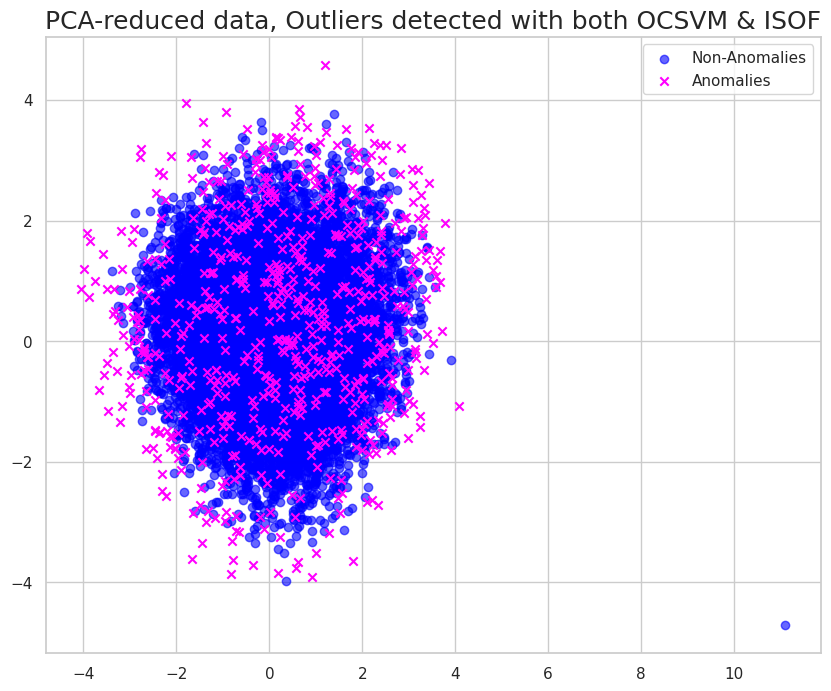

In [45]:
# convert values back to 1 and -1 for pca visualisation

engine_data_full_binary['Anomalies'] = engine_data_full_binary['Anomalies'].replace({1: -1, 0: 1})

engine_data_full_binary.head(5)

# visualise with PCA after concatenating

engine_data_full_PCA = concat_y_PCA(engine_data_pca, engine_data_full_binary['Anomalies'])
plot_outliers(engine_data_full_PCA, 'PCA-reduced data, Outliers detected with both OCSVM & ISOF')

As a measure of agreement, we can see general concretation of anomalies classified by both models around the cluster's periphery (as well as some concretation in the centre of the normal observation cluster).

### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]